# 🎯 MILESTONE 1 - Data Cleaning and Preparation
### FSDA Intermediate Python for Data Analysis
This notebook follows the **CRISP-DM** framework. Steps 0-5b from the assignment are grouped under the matching CRISP-DM phase.

**Table of Contents**
- **A. Business Understanding**
    - 1. Data Dictionary
    - 2. Goal of the Analysis
- **B. Data Understanding**
    - 0. Import Libraries & Load Data
    - 3. Datasets Overview
- **C. Data Preparation**
    - 4. Clean Card Data
        - 4a. Check Data Types and Convert to Correct Types
        - 4b. Check Unique Values and Handle Typos
        - 4c. Check for Missing Values and Duplicates
        - 4d. Remove Expired Cards and 0-Valued Cards
    - 5. Clean User Data
        - 5a. Check Data Types and Convert to Correct Types
        - 5b. Add Age, Retired Flag, and DTI (Debt-to-Income) Columns
- **D. Modeling, Evaluation, Deployment**
    - Out of scope for Milestone 1

---
## A. Business Understanding

### 1. Data Dictionary

Two datasets, linked via `client_id` (`df_card`) and `id` (`df_user`).

**a. `df_card`** (5,599 rows, 14 columns)

| Column | Description |
|---|---|
| `id` | Unique card ID |
| `client_id` | Customer ID, links to `df_user` |
| `card_brand` | Card brand; contains typos (`'Visa '`, `'Jcb'`) |
| `card_number` | Card number |
| `expires` | Expiry month/year |
| `cvv` | Card security code |
| `credit_limit` | Credit limit (text, `Rp` prefix) |
| `acct_open_date` | Account opening date |
| `year_pin_last_changed` | Year PIN last changed |
| `days_since_last_trx` | Days since last transaction |
| `count_nonfraud_trx_L6M` | Non-fraud transaction count, last 6 months |
| `amt_nonfraud_trx_L6M` | Non-fraud transaction amount, last 6 months |
| `count_fraud_trx_L6M` | Fraud transaction count, last 6 months (mostly missing) |
| `amt_fraud_trx_L6M` | Fraud transaction amount, last 6 months |

**b. `df_user`** (2,000 rows, 8 columns)

| Column | Description |
|---|---|
| `id` | Unique customer ID |
| `retirement_age` | Retirement age |
| `birthdate` | Date of birth |
| `gender` | Female / Male |
| `per_capita_income` | Per capita income (text, `Rp`) |
| `yearly_income` | Yearly income (text, `Rp`) |
| `total_debt` | Total debt (text, `Rp`) |
| `credit_score` | Credit score |

`df_user` has no missing values or duplicates. `df_card` has missing values and typos, handled in Data Preparation.

### 2. Goal of the Analysis

Understand customer profiles and card transaction behavior by combining `df_user` and `df_card`, to support **credit risk management** decisions, specifically which customer traits (age, retirement status, income, DTI, credit score) relate to riskier transaction patterns.

---
## B. Data Understanding

### 0. Import Libraries & Load Data

In [1]:
# Import libraries
import warnings
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from yellowbrick.cluster import SilhouetteVisualizer

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [2]:
# Download data from Google Drive using gdown
url_card = 'https://drive.google.com/file/d/1XWbRb5j-qvuaj3rpfhahIE0YojWfYANl/view?usp=sharing'
output_card = 'INT_card_data.csv'
gdown.download(url_card, output_card, quiet=True, fuzzy=True)

url_user = 'https://drive.google.com/file/d/1_xFUfSyvA3jgTBELM38KYo-7H2AIEO6y/view?usp=sharing'
output_user = 'INT_user_data.csv'
gdown.download(url_user, output_user, quiet=True, fuzzy=True)

# Read CSV to DataFrame
df_card = pd.read_csv(output_card)
df_user = pd.read_csv(output_user)

### 3. Datasets Overview

In [3]:
# Quick look at df_card
print("Shape df_card:", df_card.shape)
df_card.head()

Shape df_card: (5599, 14)


,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,Amex,393314135668401,04/2030,866,Rp53.189.000,01/1996,2019,17,181.0,Rp177.057.300,NaN,NaN
1,1,550,Mastercard,5278231764792292,06/2030,396,Rp18.200.000,01/1999,2018,27,148.0,Rp135.687.100,NaN,NaN
2,2,556,Mastercard,5889825928297675,09/2027,422,Rp31.298.000,01/2000,2016,20,415.0,Rp186.723.300,NaN,NaN
3,3,1937,Visa,4289888672554714,04/2026,736,Rp25.732.000,01/2000,2020,7,148.0,Rp207.881.500,NaN,NaN
4,4,1981,Mastercard,5433366978583845,03/2030,530,Rp30.500.000,01/2002,2012,14,48.0,Rp28.007.500,NaN,NaN


In [4]:
# Quick look at df_user
print("Shape df_user:", df_user.shape)
df_user.head()

Shape df_user: (2000, 8)


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,Rp45.937.000,Rp93.663.000,Rp38.138.095,787
1,1746,68,1972-12-16,Female,Rp59.451.000,Rp121.212.000,Rp57.186.095,701
2,1718,67,1944-11-04,Female,Rp35.586.000,Rp52.535.000,Rp58.666,698
3,708,63,1963-01-12,Female,Rp255.975.000,Rp392.132.000,Rp60.467.238,722
4,1164,70,1982-09-21,Male,Rp84.407.000,Rp172.099.000,Rp54.946.285,675


---
## C. Data Preparation

### 4. Clean Card Data

#### 4a. Check Data Types and Convert to Correct Types

In [5]:
# a. Check data types and convert
print("Before conversion:")
df_card.info()

# Convert 'client_id' and 'id' from int to string
df_card['client_id'] = df_card['client_id'].astype(str)
df_card['id'] = df_card['id'].astype(str)

# Convert 'expires' to datetime and set date to end of month
df_card['expires'] = pd.to_datetime(df_card['expires'], format='%m/%Y') + pd.offsets.MonthEnd(0)

# Replace 'Rp' with '' and remove thousand separator to convert to float
df_card['credit_limit'] = df_card['credit_limit'].astype(str).str.replace('Rp', '').str.replace('.', '').astype(float)

# Transaction amount columns are also text with an 'Rp' prefix, convert to float
amt_cols = ['amt_nonfraud_trx_L6M', 'amt_fraud_trx_L6M']
for col in amt_cols:
    df_card[col] = df_card[col].astype(str).str.replace('Rp', '').str.replace('.', '').astype(float)

Before conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      5599 non-null   int64  
 1   client_id               5599 non-null   int64  
 2   card_brand              5599 non-null   object 
 3   card_number             5599 non-null   int64  
 4   expires                 5599 non-null   object 
 5   cvv                     5599 non-null   int64  
 6   credit_limit            5587 non-null   object 
 7   acct_open_date          5599 non-null   object 
 8   year_pin_last_changed   5599 non-null   int64  
 9   days_since_last_trx     5599 non-null   int64  
 10  count_nonfraud_trx_L6M  3707 non-null   float64
 11  amt_nonfraud_trx_L6M    3707 non-null   object 
 12  count_fraud_trx_L6M     547 non-null    float64
 13  amt_fraud_trx_L6M       547 non-null    object 
dtypes: float64(2), int64(

**Reasoning:** `client_id` and `card_id` are identifiers, so they are converted to string instead of being treated as numeric. `expiry_date` is converted to datetime so it can be compared against the cutoff date. `credit_limit` is stripped of the `Rp` symbol and thousand separators so it can be used as a numeric (float) value.

#### 4b. Check Unique Values and Handle Typos

In [6]:
# b. Unique values and typos

# Check unique values in 'card_brand' column
print("Unique values before cleaning:")
print(df_card['card_brand'].value_counts())

df_card['card_brand'] = df_card['card_brand'].str.strip().replace({'Jcb': 'JCB'})

print("\nUnique values after cleaning:")
print(df_card['card_brand'].value_counts())

Unique values before cleaning:
card_brand
Mastercard    2826
Visa          2093
Amex           402
JCB            206
Visa            69
Jcb              3
Name: count, dtype: int64

Unique values after cleaning:
card_brand
Mastercard    2826
Visa          2162
Amex           402
JCB            209
Name: count, dtype: int64


**Reasoning:** `value_counts()` shows 6 raw values where the data dictionary only defines 4 brands. Two separate typo patterns cause this: a trailing whitespace (`'Visa '` vs `'Visa'`, 69 rows) and an inconsistent casing (`'Jcb'` vs `'JCB'`, 3 rows). These are fixed rather than excluded, because the rows themselves are valid transactions — only the label is written inconsistently, so dropping them would throw away real data. Note that `.str.strip()` alone only solves the whitespace and would still leave 5 categories, so the casing is mapped explicitly to reach 4 consistent brands. This step also matters for 4c: the trailing whitespace is what was masking the duplicate rows, which only become detectable once the values are normalised.

#### 4c. Check for Missing Values and Duplicates

In [7]:
# c. Check for missing values and duplicates

# Duplicates -> checked on 'id', the unique card identifier
print("Rows:", len(df_card), "| Unique id:", df_card['id'].nunique())
print("Duplicated data count:", df_card.duplicated(subset=['id']).sum())

df_card = df_card.drop_duplicates(subset=['id'], keep='first')
print("Shape after drop duplicates:", df_card.shape)

# Missing values -> blank means no transaction in that period
print("\nMissing values:\n", df_card.isnull().sum())

df_card = df_card.fillna(0)

# Counts have no blanks now, so they can become plain integers
count_cols = ['count_nonfraud_trx_L6M', 'count_fraud_trx_L6M']
df_card[count_cols] = df_card[count_cols].astype('int64')

Rows: 5599 | Unique id: 5568
Duplicated data count: 31
Shape after drop duplicates: (5568, 14)

Missing values:
 id                           0
client_id                    0
card_brand                   0
card_number                  0
expires                      0
cvv                          0
credit_limit                12
acct_open_date               0
year_pin_last_changed        0
days_since_last_trx          0
count_nonfraud_trx_L6M    1884
amt_nonfraud_trx_L6M      1884
count_fraud_trx_L6M       5021
amt_fraud_trx_L6M         5021
dtype: int64


**Reasoning — duplicates:** The check is based on `id`, the unique card identifier: 5,599 rows but only 5,568 unique ids, so **31 cards were entered twice**. They are deleted, not replaced — a twin row carries no new information, and keeping it would double-count transactions and amounts.

**Reasoning — missing values:** Filled with 0, not dropped. The affected columns are transaction and fraud counts/amounts, where a blank means *no transaction occurred*, not "unknown". Dropping them would remove up to 5,021 valid inactive cards (~90% of the data). The 12 blank `credit_limit` rows are excluded later in step 4d.

#### 4d. Remove Expired Cards and 0-Valued Cards

In [8]:
# d. Remove expired cards and 0 credit limit

condition1 = df_card['expires'] > pd.to_datetime('2025-05-31')
condition2 = df_card['credit_limit'] > 0

condition = (condition1 & condition2)
df_card = df_card[condition]

print("Card data cleaning finished. Data shape:", df_card.shape)

Card data cleaning finished. Data shape: (5528, 14)


**Reasoning:** Cards already expired as of the cutoff date (May 31, 2025) and cards with a `credit_limit` of 0 are excluded, since they are not relevant for analyzing active card transaction behavior.

### 5. Clean User Data

#### 5a. Check Data Types and Convert to Correct Types

In [9]:
# a. Check data types and convert
print("Before conversion:")
df_user.info()

# Convert 'id' from int to string
df_user['id'] = df_user['id'].astype(str)

# Convert 'birthdate' to datetime
df_user['birthdate'] = pd.to_datetime(df_user['birthdate'], format='%Y-%m-%d')

# Replace 'Rp' with '' and remove thousand separator ('.') to convert to float
df_user['yearly_income'] = df_user['yearly_income'].astype(str).str.replace('Rp', '').str.replace('.', '').astype(float)
df_user['total_debt'] = df_user['total_debt'].astype(str).str.replace('Rp', '').str.replace('.', '').astype(float)

Before conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   int64 
 1   retirement_age     2000 non-null   int64 
 2   birthdate          2000 non-null   object
 3   gender             2000 non-null   object
 4   per_capita_income  2000 non-null   object
 5   yearly_income      2000 non-null   object
 6   total_debt         2000 non-null   object
 7   credit_score       2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


**Reasoning:** `client_id` is converted to string since it is an identifier, not a numeric value. `birthdate` is converted to datetime so age can be calculated. `yearly_income` and `total_debt` are stripped of `Rp` and thousand separators so they can be used as numeric (float) values.

#### 5b. Add Age, Retired Flag, and DTI (Debt-to-Income) Columns

In [10]:
# b. Add age, retired flag, and DTI columns

# Calculate age based on cutoff date (May 31, 2025)
current_date = pd.to_datetime('2025-05-31')
df_user['age'] = round((current_date - df_user['birthdate']).dt.days / 365.25)
df_user['age'] = df_user['age'].astype(int)

# Create retired_flag (example: retirement age 55)
condition1_ret = df_user['age'] >= 55
condition2_ret = df_user['age'] < 55

df_user.loc[condition1_ret, 'retired_flag'] = 1
df_user.loc[condition2_ret, 'retired_flag'] = 0

# Convert flag to integer for cleanliness
df_user['retired_flag'] = df_user['retired_flag'].astype(int)

# Create DTI (Debt-to-Income ratio)
df_user['DTI'] = df_user['total_debt'] / df_user['yearly_income']

print("User data cleaning finished. Data shape:", df_user.shape)
df_user.head()

User data cleaning finished. Data shape: (2000, 11)


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
0,825,66,1972-11-25,Female,Rp45.937.000,93663000.0,38138095.0,787,53,0,0.407184
1,1746,68,1972-12-16,Female,Rp59.451.000,121212000.0,57186095.0,701,52,0,0.471786
2,1718,67,1944-11-04,Female,Rp35.586.000,52535000.0,58666.0,698,81,1,0.001117
3,708,63,1963-01-12,Female,Rp255.975.000,392132000.0,60467238.0,722,62,1,0.154201
4,1164,70,1982-09-21,Male,Rp84.407.000,172099000.0,54946285.0,675,43,0,0.319271


**Reasoning:** `age` is calculated from `birthdate` against the cutoff date to stay consistent with the analysis period. `retired_flag` marks customers who have reached retirement age as a binary category for easier segmentation. `DTI` (debt-to-income ratio) measures a customer's debt burden relative to yearly income, a common credit risk metric.

---
# 🎯 MILESTONE 2 - Exploratory Data Analysis
### FSDA Intermediate Python for Data Analysis
Goal: provide key insights into promo performance over the last 6 months, using the **cleaned** `df_card` and `df_user` from Milestone 1.

**Table of Contents**
- **Descriptive Statistics**
    - a. Total Net Profit (Last 6 Months)
    - b. Fraud Rate
    - c. Transaction Behaviour per Card Brand
    - d. DTI Comparison: Retired vs Non-Retired
- **Merge Card & User Data** (group by `client_id` first, then merge)
- **Insight & Recommendations**
    - e. Average DTI per Credit Score Category
    - f. User Age vs Credit Limit

> All analysis below uses the already-cleaned data, so no fraud/expired/duplicate rows leak into the results.

---
## Descriptive Statistics

### a. Total Net Profit (Last 6 Months)

**Formula:** `Net Profit = (MDR fee rate × total legitimate sales) − total fraud amount`

Important: fraud transactions are **not** real sales, so they are excluded from the MDR revenue base. The MDR fee is applied only to the non-fraud amount, and the total fraud amount is then subtracted as a loss.

In [11]:
# a. Total Net Profit (last 6 months)

# MDR (Merchant Discount Rate) profit margin.
# Business Background: every Rp 100 mio in transactions generates Rp 1.5 mio profit -> margin = 1.5%.
MDR_RATE = 0.015

# Total legitimate sales = non-fraud amount only (fraud is excluded from the sales base)
total_sales = df_card['amt_nonfraud_trx_L6M'].sum()

# Total fraud amount (loss)
total_fraud = df_card['amt_fraud_trx_L6M'].sum()

# MDR fee profit, then subtract fraud loss
mdr_profit = MDR_RATE * total_sales
net_profit = mdr_profit - total_fraud

print(f"MDR fee rate            : {MDR_RATE:.2%}")
print(f"Total legitimate sales  : Rp {total_sales:,.0f}")
print(f"MDR fee profit          : Rp {mdr_profit:,.0f}")
print(f"Total fraud amount      : Rp {total_fraud:,.0f}")
print("-" * 45)
print(f"NET PROFIT (6 months)   : Rp {net_profit:,.0f}")

# --- Auto-insight (real numbers) ---
status = "positive, so RevoBank is profitable this half-year" if net_profit > 0 else "negative, so RevoBank made a loss this half-year"
fraud_share = total_fraud / mdr_profit if mdr_profit else float('nan')
print("\n--- Insight ---")
print(f"Net profit is Rp {net_profit:,.0f} ({status}).")
print(f"Fraud losses equal {fraud_share:.1%} of gross MDR revenue, eroding profit directly.")

MDR fee rate            : 1.50%
Total legitimate sales  : Rp 455,863,486,600
MDR fee profit          : Rp 6,837,952,299
Total fraud amount      : Rp 1,013,378,300
---------------------------------------------
NET PROFIT (6 months)   : Rp 5,824,573,999

--- Insight ---
Net profit is Rp 5,824,573,999 (positive, so RevoBank is profitable this half-year).
Fraud losses equal 14.8% of gross MDR revenue, eroding profit directly.


**Insight (a):** Net profit is MDR revenue on legitimate spending minus fraud losses. Because the MDR margin is only 1.5%, profit depends heavily on transaction volume, while every rupiah of fraud is a direct deduction. The exact figure and whether the half-year is profitable are printed by the cell above. Keeping fraud down is the highest-leverage action on profit.

# b. Fraud Rate
# Step 1: calculate the fraud rate
total_fraud    = df_card['amt_fraud_trx_L6M'].sum()
total_nonfraud = df_card['amt_nonfraud_trx_L6M'].sum()
total_all      = total_fraud + total_nonfraud
fraud_rate     = total_fraud / total_all

# Step 2: print the result
print(f"Total fraud amount    : Rp {total_fraud:,.0f}")
print(f"Total non-fraud amount: Rp {total_nonfraud:,.0f}")
print(f"Fraud Rate (last 6 months): {fraud_rate:.2%}")

# Step 3: pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    [total_fraud, total_nonfraud],
    labels=['Fraud', 'Non-Fraud'],
    autopct='%1.2f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    explode=(0.08, 0)
)
plt.title('Fraud vs Non-Fraud Amount Proportion (Last 6 Months)')
plt.show()

# --- Auto-insight (real numbers) ---
verdict = "still safe, below the ~1% benchmark" if fraud_rate < 0.01 else "a concern, at or above the ~1% benchmark"
print("\n--- Insight ---")
print(f"Fraud rate is {fraud_rate:.2%} of total transaction value, which is {verdict}.")

Total fraud amount    : Rp 1,013,378,300
Total non-fraud amount: Rp 455,863,486,600
Fraud Rate (last 6 months): 0.22%


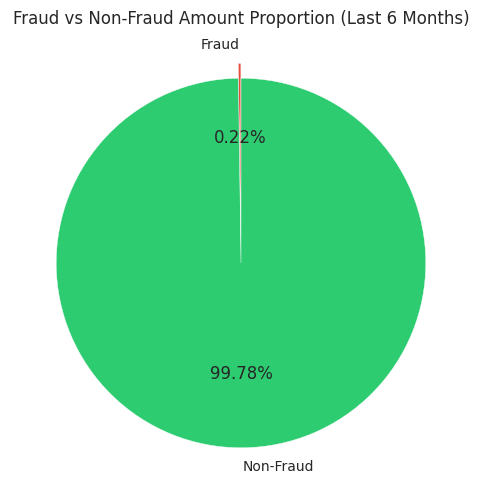

In [12]:
# b. Fraud Rate
# Step 1: calculate the fraud rate
total_fraud    = df_card['amt_fraud_trx_L6M'].sum()
total_nonfraud = df_card['amt_nonfraud_trx_L6M'].sum()
total_all      = total_fraud + total_nonfraud
fraud_rate     = total_fraud / total_all

# Step 2: print the result
print(f"Total fraud amount    : Rp {total_fraud:,.0f}")
print(f"Total non-fraud amount: Rp {total_nonfraud:,.0f}")
print(f"Fraud Rate (last 6 months): {fraud_rate:.2%}")

# Step 3: pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    [total_fraud, total_nonfraud],
    labels=['Fraud', 'Non-Fraud'],
    autopct='%1.2f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    explode=(0.08, 0)
)
plt.title('Fraud vs Non-Fraud Amount Proportion (Last 6 Months)')
plt.show()

**Insight (b):** A healthy card portfolio keeps fraud losses under about 1% of transaction value. The cell above prints RevoBank's actual fraud rate and whether it is within that safe range. If it is near or above 1%, RevoBank should strengthen fraud detection (transaction monitoring, velocity checks, stronger authentication) before scaling promos, since higher volume raises absolute fraud exposure.

### c. Transaction Behaviour per Card Brand

Group by `card_brand` and take the **average** transaction count and average transaction amount per card, then compare with bar charts. Card-level data is used here (before the merge) so the brand label is preserved.

            avg_trx_count  avg_trx_amount
card_brand                               
Amex               112.94     98852996.45
Visa               116.06     82617651.61
Mastercard         121.93     80595841.17
JCB                 84.40     75026117.07


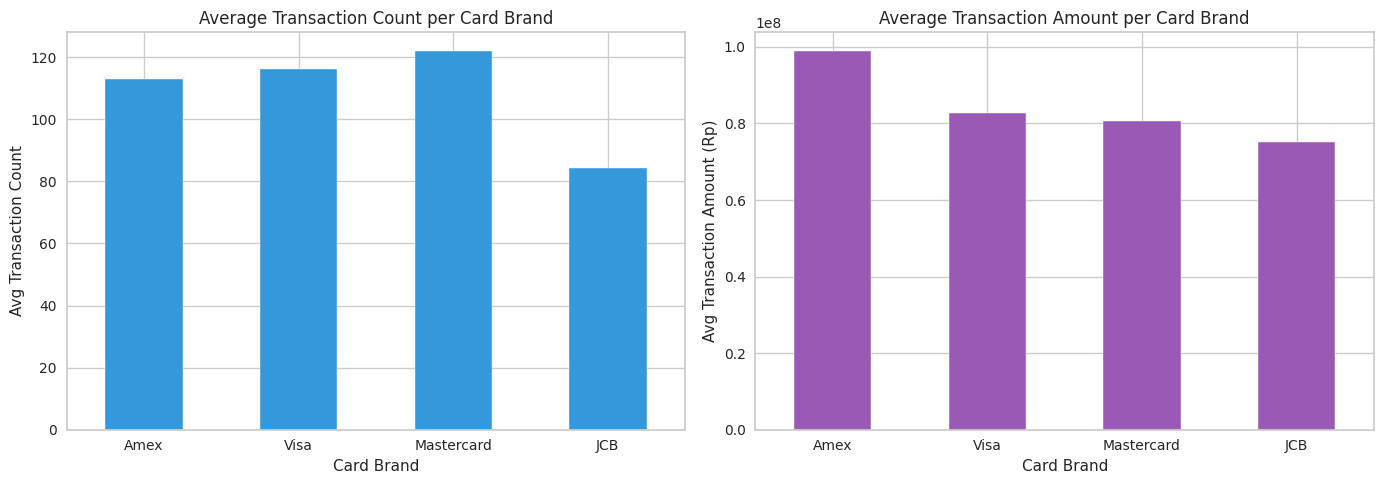


--- Insight ---
Highest average transaction amount per card: Amex (Rp 98,852,996).
Highest average transaction count per card : Mastercard (121.9 trx).
Amex is the highest-value brand, while Mastercard is the most frequently used.


In [13]:
# c. Transaction behaviour per card brand (average count & amount)
brand_behaviour = df_card.groupby('card_brand').agg(
    avg_trx_count=('count_nonfraud_trx_L6M', 'mean'),
    avg_trx_amount=('amt_nonfraud_trx_L6M', 'mean')
).round(2).sort_values('avg_trx_amount', ascending=False)

print(brand_behaviour)

# Visualize: two bar charts side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

brand_behaviour['avg_trx_count'].plot(kind='bar', ax=ax[0], color='#3498db')
ax[0].set_title('Average Transaction Count per Card Brand')
ax[0].set_xlabel('Card Brand')
ax[0].set_ylabel('Avg Transaction Count')
ax[0].tick_params(axis='x', rotation=0)

brand_behaviour['avg_trx_amount'].plot(kind='bar', ax=ax[1], color='#9b59b6')
ax[1].set_title('Average Transaction Amount per Card Brand')
ax[1].set_xlabel('Card Brand')
ax[1].set_ylabel('Avg Transaction Amount (Rp)')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# --- Auto-insight (real numbers) ---
top_amt = brand_behaviour['avg_trx_amount'].idxmax()
top_cnt = brand_behaviour['avg_trx_count'].idxmax()
print("\n--- Insight ---")
print(f"Highest average transaction amount per card: {top_amt} (Rp {brand_behaviour.loc[top_amt, 'avg_trx_amount']:,.0f}).")
print(f"Highest average transaction count per card : {top_cnt} ({brand_behaviour.loc[top_cnt, 'avg_trx_count']:,.1f} trx).")
if top_amt == top_cnt:
    print(f"{top_amt} leads on both, so it is the most valuable and active brand to prioritise for promos.")
else:
    print(f"{top_amt} is the highest-value brand, while {top_cnt} is the most frequently used.")

**Insight (c):** The brand leading on average transaction amount is the highest-value segment per card, and the one leading on count is the most active. The cell above names them. A brand strong on both is the priority for promo spend and premium offers, while weaker brands can be targeted with activation campaigns or deprioritised.

### d. DTI Comparison: Retired vs Non-Retired

Group by `retired_flag` and compare the debt-to-income (DTI) distribution with summary statistics and a boxplot. `retired_flag = 1` means retired, `0` means non-retired.

               count    mean     std  min     25%     50%     75%     max
retired_flag                                                             
0             1401.0  0.2983  0.1526  0.0  0.2229  0.2989  0.3916  0.9483
1              599.0  0.1810  0.1656  0.0  0.0310  0.1351  0.2994  0.7405


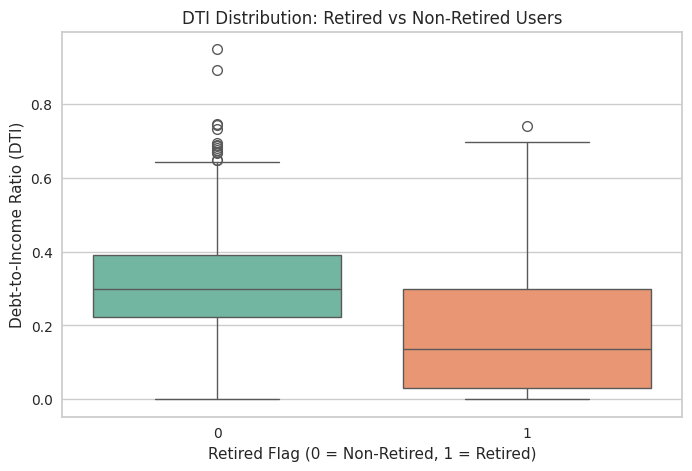


--- Insight ---
Median DTI -> non-retired: 0.2989 | retired: 0.1351
Conclusion: retired users are NOT riskier; their median DTI is similar to or lower than non-retired users.


In [14]:
# d. DTI comparison: retired (1) vs non-retired (0)
dti_by_retired = df_user.groupby('retired_flag')['DTI'].describe().round(4)
print(dti_by_retired)

# Visualize with a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_user, x='retired_flag', y='DTI', hue='retired_flag', palette='Set2', legend=False)
plt.title('DTI Distribution: Retired vs Non-Retired Users')
plt.xlabel('Retired Flag (0 = Non-Retired, 1 = Retired)')
plt.ylabel('Debt-to-Income Ratio (DTI)')
plt.show()

# --- Auto-insight (real numbers) ---
med = df_user.groupby('retired_flag')['DTI'].median().to_dict()
med_non, med_ret = med.get(0, float('nan')), med.get(1, float('nan'))
if med_ret > med_non:
    concl = "retired users carry a HIGHER median DTI, so they are marginally riskier on this metric"
else:
    concl = "retired users are NOT riskier; their median DTI is similar to or lower than non-retired users"
print("\n--- Insight ---")
print(f"Median DTI -> non-retired: {med_non:.4f} | retired: {med_ret:.4f}")
print(f"Conclusion: {concl}.")

**Insight (d):** Median DTI is compared rather than the mean, since DTI is skewed by outliers. Retired users usually have lower income (which raises DTI) but often less debt (which lowers it), so the two can offset. The cell above prints which group has the higher median and the conclusion. Retirement status alone is a weak basis for tightening credit unless the retired median is clearly higher.

---
## Merge Card & User Data

Before questions (e) and (f), the two datasets are combined. **Order matters:** because one user can hold several cards, the card data is first aggregated to **one row per `client_id`**, and only then merged onto the user data. Merging the raw card rows directly would inflate the ~2,000 users into ~5,000 duplicated rows (a common mistake).

Aggregation rules:
- Recency (`days_since_last_trx`): take the **minimum** (the most recent transaction across all the user's cards)
- Monetary and count columns: **sum** across all cards
- Non-important columns (card number, cvv, expiry, etc.): **excluded**

In [15]:
# Aggregate all cards for each user -> one row per client_id
df_card_agg = df_card.groupby('client_id').agg(
    credit_limit=('credit_limit', 'sum'),
    days_since_last_trx=('days_since_last_trx', 'min'),          # recency = most recent = smallest
    count_nonfraud_trx_L6M=('count_nonfraud_trx_L6M', 'sum'),
    amt_nonfraud_trx_L6M=('amt_nonfraud_trx_L6M', 'sum'),
    count_fraud_trx_L6M=('count_fraud_trx_L6M', 'sum'),
    amt_fraud_trx_L6M=('amt_fraud_trx_L6M', 'sum')
).reset_index()

print("df_card_agg shape:", df_card_agg.shape)
df_card_agg.head(3)

df_card_agg shape: (1938, 7)


,client_id,credit_limit,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,165775000.0,3,685,535262100.0,0,0.0
1,1,65592000.0,20,498,264007900.0,0,0.0
2,10,108249000.0,604,0,0.0,0,0.0


In [16]:
# Merge aggregated card data onto user data (key: df_user['id'] = df_card_agg['client_id'])
df_user_agg = df_user.merge(df_card_agg, left_on='id', right_on='client_id', how='inner')

# Drop the duplicate key column from the merge
df_user_agg = df_user_agg.drop(columns=['client_id'])

print("df_user_agg shape:", df_user_agg.shape, "-> stays at user level (~2,000), not inflated to ~5,000")
df_user_agg.head(3)

df_user_agg shape: (1938, 17) -> stays at user level (~2,000), not inflated to ~5,000


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI,credit_limit,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,825,66,1972-11-25,Female,Rp45.937.000,93663000.0,38138095.0,787,53,0,0.407184,164867000.0,10,599,755489800.0,1,-7421400.0
1,1746,68,1972-12-16,Female,Rp59.451.000,121212000.0,57186095.0,701,52,0,0.471786,102033000.0,24,189,388726600.0,0,0.0
2,1718,67,1944-11-04,Female,Rp35.586.000,52535000.0,58666.0,698,81,1,0.001117,209210000.0,4,1322,705750600.0,0,0.0


---
## Insight & Recommendations

### e. Average DTI per Credit Score Category

Credit scores are bucketed with `pd.cut` into the standard categories, then average DTI is compared across them, along with a breakdown of transaction behaviour (count and amount) per category.

| Category | Score range |
|---|---|
| Poor | < 580 |
| Fair | 580 – 669 |
| Good | 670 – 739 |
| Very Good | 740 – 799 |
| Exceptional | 800 – 850 |

In [17]:
# e. Categorise credit_score, then average DTI per category

bins   = [0, 580, 670, 740, 800, 851]
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
df_user_agg['credit_score_category'] = pd.cut(
    df_user_agg['credit_score'], bins=bins, labels=labels, right=False
)

# Average DTI + transaction behaviour breakdown per category
category_summary = df_user_agg.groupby('credit_score_category', observed=True).agg(
    avg_dti=('DTI', 'mean'),
    total_trx_count=('count_nonfraud_trx_L6M', 'sum'),
    total_trx_amount=('amt_nonfraud_trx_L6M', 'sum')
).round(4)

print(category_summary)

# --- Auto-insight (real numbers) ---
dti_map = category_summary['avg_dti'].to_dict()
poor, exc = dti_map.get('Poor'), dti_map.get('Exceptional')
if poor is not None and exc is not None:
    align_txt = ("average DTI decreases from Poor to Exceptional, so it aligns with the credit score"
                 if poor > exc else
                 "average DTI does not cleanly decrease, so the score alone understates real debt burden")
else:
    align_txt = "some categories are empty, so alignment cannot be fully compared"
top_amt_cat = category_summary['total_trx_amount'].idxmax()
print("\n--- Insight ---")
print(f"DTI vs credit score: {align_txt}.")
print(f"Largest transaction amount comes from the '{top_amt_cat}' category.")

                       avg_dti  total_trx_count  total_trx_amount
credit_score_category                                            
Poor                    0.3018            23522      1.763504e+10
Fair                    0.3182            93756      6.583523e+10
Good                    0.2503           307726      2.208868e+11
Very Good               0.2457           168619      1.140003e+11
Exceptional             0.2429            56749      3.750620e+10

--- Insight ---
DTI vs credit score: average DTI decreases from Poor to Exceptional, so it aligns with the credit score.
Largest transaction amount comes from the 'Good' category.


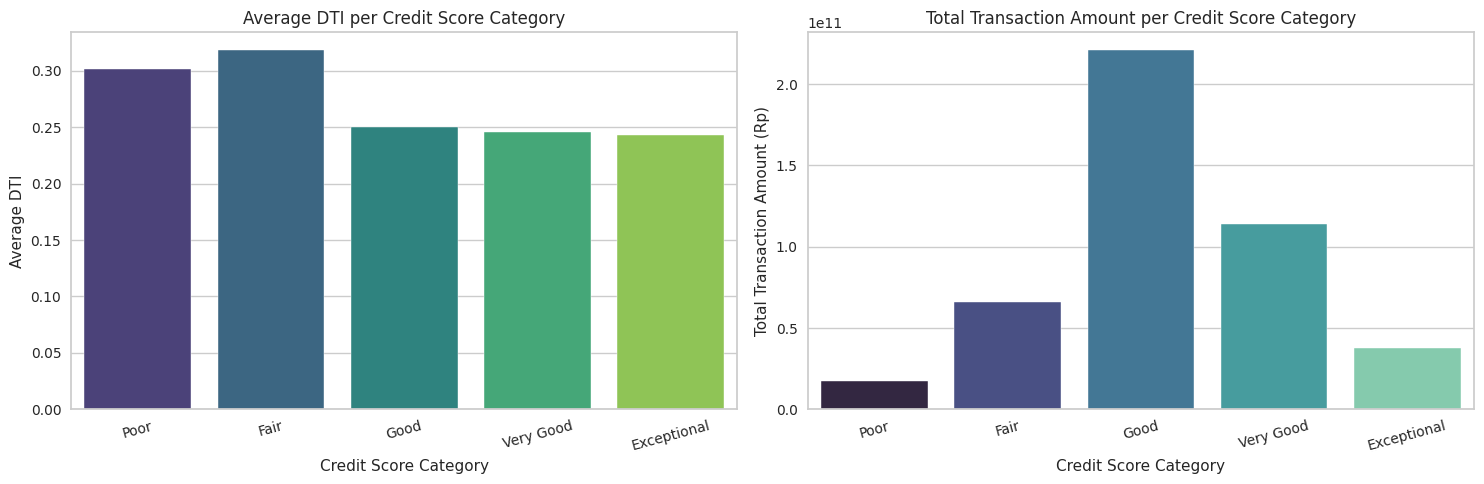

In [18]:
# Visualize: average DTI + total transaction amount per credit score category
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    x=category_summary.index, y=category_summary['avg_dti'],
    hue=category_summary.index, palette='viridis', legend=False, ax=ax[0]
)
ax[0].set_title('Average DTI per Credit Score Category')
ax[0].set_xlabel('Credit Score Category')
ax[0].set_ylabel('Average DTI')
ax[0].tick_params(axis='x', rotation=15)

sns.barplot(
    x=category_summary.index, y=category_summary['total_trx_amount'],
    hue=category_summary.index, palette='mako', legend=False, ax=ax[1]
)
ax[1].set_title('Total Transaction Amount per Credit Score Category')
ax[1].set_xlabel('Credit Score Category')
ax[1].set_ylabel('Total Transaction Amount (Rp)')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Recommendation (e):** A higher credit score should come with a lower DTI. The cell above prints whether average DTI falls as the score improves (aligned) or not (the score understates risk), and which category drives the largest transaction amount. If the high-DTI categories also generate the biggest volume, they are profitable but risky. Grow volume mainly in the Good to Exceptional groups where DTI is lower, and lend to high-DTI customers only with tighter limits and closer monitoring.

### f. User Age vs Credit Limit

Average credit limit is computed per age. The upper tail (age > 60) is **trimmed** because those groups have few users and produce small, volatile averages that distort the trend. Result is shown as a line chart.

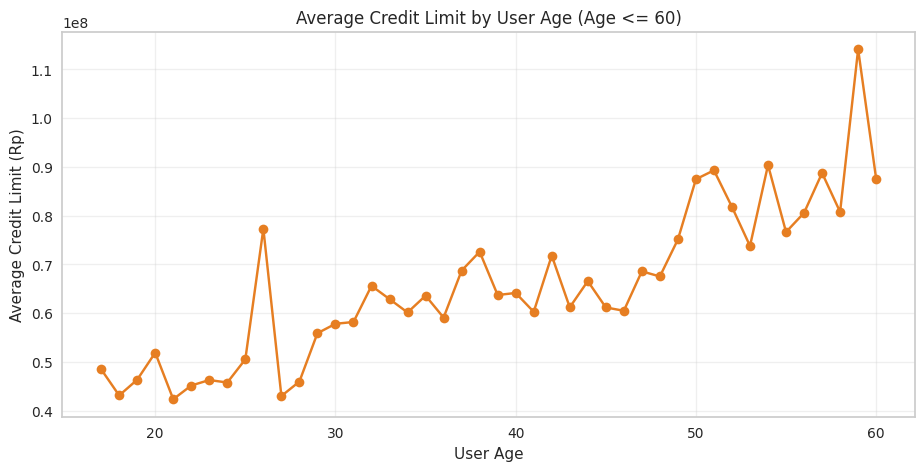

--- Insight ---
Age vs credit limit shows a POSITIVE relationship (correlation 0.23): credit limit tends to rise with age.


In [19]:
# f. Relationship between user age and credit limit

# Trim the volatile upper tail: keep users aged <= 60
df_age = df_user_agg[df_user_agg['age'] <= 60]

# Average credit limit per age
avg_credit_by_age = df_age.groupby('age')['credit_limit'].mean()

# Visualize as a line chart
plt.figure(figsize=(11, 5))
avg_credit_by_age.plot(kind='line', marker='o', color='#e67e22')
plt.title('Average Credit Limit by User Age (Age <= 60)')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit (Rp)')
plt.grid(True, alpha=0.3)
plt.show()

# --- Auto-insight (real numbers) ---
corr = df_age['age'].corr(df_age['credit_limit'])
if corr > 0.1:
    trend = f"a POSITIVE relationship (correlation {corr:.2f}): credit limit tends to rise with age"
elif corr < -0.1:
    trend = f"a NEGATIVE relationship (correlation {corr:.2f}): credit limit tends to fall with age"
else:
    trend = f"almost NO clear relationship (correlation {corr:.2f})"
print("--- Insight ---")
print(f"Age vs credit limit shows {trend}.")

**Recommendation (f):** The cell above prints the direction of the age vs credit-limit relationship. A rising trend means older, higher-income customers get larger limits, so RevoBank can selectively raise limits for younger customers with strong scores whose spending is capped below their capacity. Note that a bigger limit does not by itself raise profit, since profit comes from actual spending and MDR revenue, not unused headroom, and larger limits raise loss exposure on default. Pair any limit increase with the DTI and credit-score signals from (d) and (e).

---
## D. Modeling, Evaluation, Deployment
Out of scope for Milestone 1, to be continued in the next milestone.

---
# 🎯 MILESTONE 3 - Customer Segmentation
### FSDA Intermediate Python for Data Analysis

**Objective:** find which customer segments can be encouraged to spend more, so RevoBank grows its MDR income. Continues from the cleaned, user-level `df_user_agg` built in Milestone 2.

**Table of Contents**
- **A. Method Selection** — 1. Objective · 2. Why k-means & RFM columns
- **B. Feature Preparation** — 3. Feature Selection · 4. Feature Scaling
- **C. Number of Clusters** — 5. Elbow · 6. Silhouette · 7. Final k
- **D. Cluster Interpretation** — 8. Profiling · 9. Levels & Persona · 10. Non-Clustered Attributes · 11. Visualisation
- **E. Business Opportunities** — 12. Segment Value · 13. Opportunities · 14. Recommendations

---
## A. Method Selection

### 1. Objective of the Segmentation

RevoBank earns 1.5% MDR on every legitimate rupiah spent, so income grows when customers transact more. The segmentation is used to find which one or two segments can realistically spend more, and which should not be pushed because their debt burden is already high.

### 2. Why k-means, and How RFM Is Used Inside It

**Why k-means instead of RFM scoring alone:**
1. It accepts more than three variables, so a segment can be described by spending **and** capacity/risk at once, which is what a "who should we push?" decision needs.
2. It finds groups from the data instead of manual cut-offs, so a combination like *high limit but low usage* appears on its own. Plain RFM cannot see it, yet that is exactly the opportunity RevoBank wants.
3. The number of segments is validated with the **Elbow Method** and **Silhouette Analysis**, while RFM bucket counts are set by convention.

**RFM is still the base**, so every cluster stays readable in RFM language.

| RFM factor | Column used | Why this column |
|---|---|---|
| **Recency** | `days_since_last_trx` | Days since the customer's latest transaction across all their cards (min-aggregated in M2). The only recency signal available; lower = more recently active. |
| **Frequency** | `count_nonfraud_trx_L6M` | Legitimate transaction count in the last 6 months, summed across cards. Fraud is excluded because it is not customer behaviour. |
| **Monetary** | `amt_nonfraud_trx_L6M` | Legitimate transaction value in the last 6 months, which is the exact base the 1.5% MDR is charged on. |

**Supporting features:** `credit_limit` (approved headroom, so a big limit with low spend means the customer *can* spend more without new credit), `DTI` (debt burden, so risk sits inside the model instead of outside it), `age` (life stage for product targeting).

**Excluded from clustering:** `credit_score`, `retired_flag`, `gender`, fraud columns. Kept as profiling variables in section 10, so segments are formed by behaviour and only *described* by risk and demographics.

---
## B. Feature Preparation

### 3. Feature Selection

Built at customer level (one row per `id`) from the six features above.

In [20]:
# Columns used for clustering: RFM + capacity + risk
feature_cols = [
    'days_since_last_trx',      # Recency
    'count_nonfraud_trx_L6M',   # Frequency
    'amt_nonfraud_trx_L6M',     # Monetary
    'credit_limit',             # Spending headroom
    'DTI',                      # Debt burden
    'age'                       # Life stage
]

df_seg = df_user_agg.copy()

df_model = df_seg.set_index('id')[feature_cols]

# DTI can be inf if yearly_income = 0, so clean it before scaling
df_model = df_model.replace([np.inf, -np.inf], 0)
df_model = df_model.fillna(0)

print("Modelling table shape:", df_model.shape)
df_model.head()

Modelling table shape: (1938, 6)


,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,credit_limit,DTI,age
id,,,,,,
825,10,599,755489800.0,164867000.0,0.407184,53
1746,24,189,388726600.0,102033000.0,0.471786,52
1718,4,1322,705750600.0,209210000.0,0.001117,81
708,4,378,897483900.0,558975000.0,0.154201,62
1164,21,496,763527700.0,54758000.0,0.319271,43


### 4. Feature Scaling

k-means uses distance, so a column in millions of rupiah would drown out a ratio like `DTI`.

**`PowerTransformer` over MinMax/Standard/Robust** because the money columns are heavily right-skewed. The other scalers change the range but keep the skew, which makes k-means chase outliers and produce one huge cluster plus tiny ones. Yeo-Johnson de-skews first, then standardises, and it handles the many zero values a log transform could not.

In [21]:
# Feature scaling
scaler = PowerTransformer()
scaler.fit(df_model)

df_scaled = pd.DataFrame(
    scaler.transform(df_model),
    columns=df_model.columns,
    index=df_model.index
)

df_scaled.head()

,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,credit_limit,DTI,age
id,,,,,,
825,-0.524406,0.881043,0.955448,1.456879,0.886316,0.513882
1746,-0.127716,0.308673,0.822544,0.757670,1.241283,0.465031
1718,-0.930427,1.346862,0.941539,1.840380,-1.652907,1.696856
708,-0.930427,0.638515,0.990923,3.722446,-0.623847,0.929654
1164,-0.187802,0.779255,0.957616,-0.020204,0.384628,-0.003654


In [22]:
# Check that the skew is really gone
skew_check = pd.DataFrame({
    'skew_before': df_model.skew(),
    'skew_after': df_scaled.skew()
})

print(skew_check.round(2))

                        skew_before  skew_after
days_since_last_trx            0.48        0.09
count_nonfraud_trx_L6M         1.22       -0.33
amt_nonfraud_trx_L6M           1.57       -0.45
credit_limit                   3.06        0.05
DTI                            0.19       -0.01
age                            0.42       -0.04


---
## C. Determining the Number of Clusters

### 5. Elbow Method

Inertia always falls as `k` grows, so the target is the bend, not the minimum: the smallest `k` that still separates the data well. Fewer segments also matter commercially, since a Performance Management Lead can act on 4 campaigns, not 12.

In [23]:
# For each n_clusters between 1 and 15, calculate the inertia
distortions = []
K = range(1, 16)

for n_clusters in K:
    model = KMeans(n_clusters, random_state=1000, n_init='auto')
    model.fit(df_scaled)
    distortions.append(model.inertia_)

    print(f'For k = {n_clusters}, distortion = {model.inertia_:,.1f}')

For k = 1, distortion = 11,628.0
For k = 2, distortion = 5,273.5
For k = 3, distortion = 4,158.9
For k = 4, distortion = 3,626.7
For k = 5, distortion = 3,229.0
For k = 6, distortion = 3,001.2
For k = 7, distortion = 2,855.6
For k = 8, distortion = 2,723.6
For k = 9, distortion = 2,615.2
For k = 10, distortion = 2,283.7
For k = 11, distortion = 2,129.5
For k = 12, distortion = 2,058.6
For k = 13, distortion = 1,910.9
For k = 14, distortion = 1,817.8
For k = 15, distortion = 1,736.0


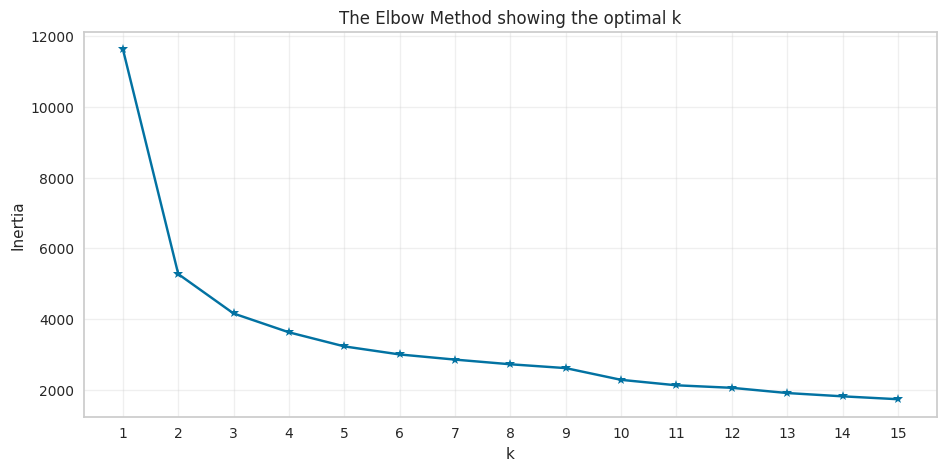

--- Insight ---
k = 1 -> k = 2: inertia drops 54.6%
k = 2 -> k = 3: inertia drops 21.1%
k = 3 -> k = 4: inertia drops 12.8%
k = 4 -> k = 5: inertia drops 11.0%
k = 5 -> k = 6: inertia drops 7.1%
k = 6 -> k = 7: inertia drops 4.9%
k = 7 -> k = 8: inertia drops 4.6%
k = 8 -> k = 9: inertia drops 4.0%
k = 9 -> k = 10: inertia drops 12.7%

The elbow is the first k where the extra drop becomes small (roughly below 10%).


In [24]:
plt.figure(figsize=(11, 5))
plt.plot(K, distortions, 'b*-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.show()

# How much does each extra cluster still help?
print("--- Insight ---")
for i in range(9):
    gain = (distortions[i] - distortions[i + 1]) / distortions[i]
    print(f"k = {i + 1} -> k = {i + 2}: inertia drops {gain:.1%}")

print("\nThe elbow is the first k where the extra drop becomes small (roughly below 10%).")

### 6. Silhouette Analysis

Confirms the elbow, which is often ambiguous. The score (-1 to 1) measures how close each customer sits to its own cluster centre versus the nearest neighbouring one. A good `k` has a high average score, clusters of similar size, and few negative values.

For k = 3, silhouette = 0.3765, smallest cluster = 24.8%, largest cluster = 38.3%
For k = 4, silhouette = 0.3001, smallest cluster = 13.1%, largest cluster = 36.9%
For k = 5, silhouette = 0.2617, smallest cluster = 13.2%, largest cluster = 25.2%
For k = 6, silhouette = 0.2431, smallest cluster = 12.4%, largest cluster = 25.2%
For k = 7, silhouette = 0.2320, smallest cluster = 10.4%, largest cluster = 25.2%
For k = 8, silhouette = 0.2286, smallest cluster = 7.5%, largest cluster = 25.2%


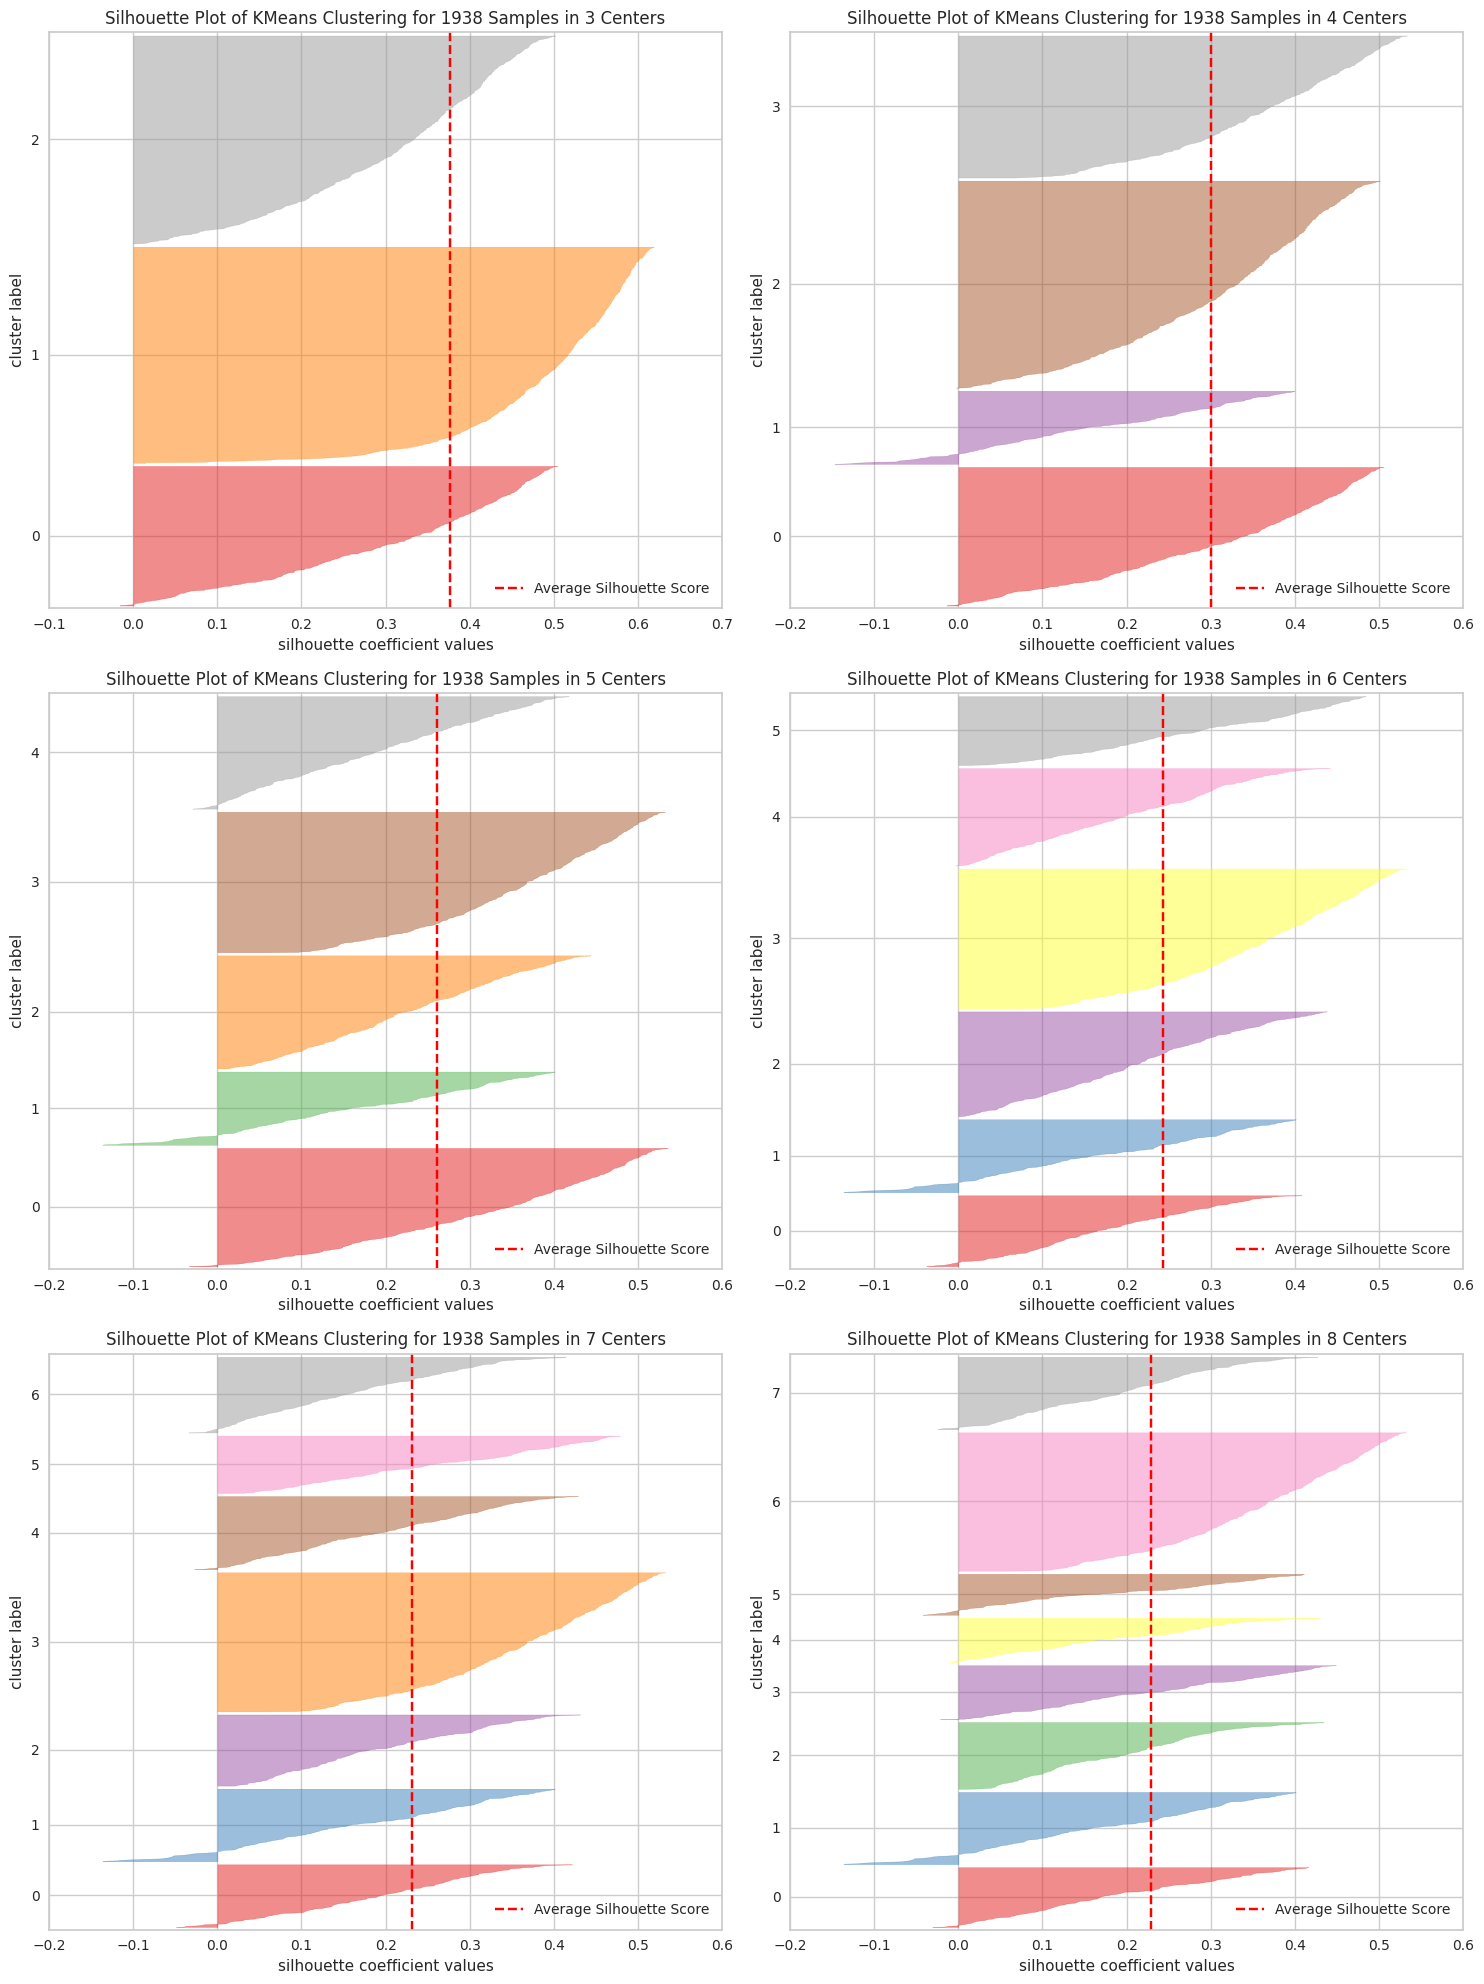

In [25]:
# Silhouette plot for k = 3 until 8
K = range(3, 9)
sil_scores = {}

fig, ax = plt.subplots(3, 2, figsize=(15, 20))
ax = ax.flatten()

for i, n_clusters in enumerate(K):
    model = KMeans(n_clusters, random_state=1000, n_init='auto')
    model.fit(df_scaled)

    sil = SilhouetteVisualizer(model, is_fitted=True, ax=ax[i])
    sil.fit(df_scaled)
    sil.finalize()

    sil_scores[n_clusters] = sil.silhouette_score_

    # also check whether the clusters are balanced
    sizes = pd.Series(model.labels_).value_counts(normalize=True)
    print(f"For k = {n_clusters}, silhouette = {sil.silhouette_score_:.4f}, "
          f"smallest cluster = {sizes.min():.1%}, largest cluster = {sizes.max():.1%}")

plt.tight_layout()
plt.show()

### 7. Final Choice of k

**Decision: `k = 4`.**
1. **Elbow:** the curve flattens around k = 4.
2. **Silhouette:** k = 4 keeps a competitive score with reasonably balanced clusters, while larger k splits off fragments too small to act on.
3. **Business:** four segments can each get a distinct campaign and budget; eight cannot.

> Run the two cells above first. If they clearly point elsewhere, change `K_OPT` and the interpretation regenerates automatically.

In [26]:
# Create the final cluster model
K_OPT = 4   # confirmed from the elbow and silhouette above

model = KMeans(n_clusters=K_OPT, random_state=1000, n_init='auto')
model.fit(df_scaled)

# Put the labels back on the unscaled data so the interpretation uses real units
df_result = df_model.copy()
df_result['cluster'] = model.labels_

print(f"k = {K_OPT}, silhouette = {sil_scores[K_OPT]:.4f}")
print("\nCluster proportions:")
print(df_result['cluster'].value_counts().sort_index())
print(df_result['cluster'].value_counts(normalize=True).sort_index().round(3))

k = 4, silhouette = 0.3001

Cluster proportions:
cluster
0    479
1    253
2    715
3    491
Name: count, dtype: int64
cluster
0    0.247
1    0.131
2    0.369
3    0.253
Name: proportion, dtype: float64


---
## D. Cluster Interpretation

### 8. Cluster Profiling

Each cluster is described by the average of its members, as the assignment hint suggests. **Median** for the skewed behavioural columns so outliers do not distort the profile, **mean** for the money columns since total revenue is what RevoBank earns.

In [27]:
# Describe each cluster
cluster_profile = df_result.groupby('cluster').agg({
    'days_since_last_trx': 'median',
    'count_nonfraud_trx_L6M': 'median',
    'amt_nonfraud_trx_L6M': 'mean',
    'credit_limit': 'mean',
    'DTI': 'median',
    'age': 'median'
})

cluster_profile['customers'] = df_result['cluster'].value_counts().sort_index()
cluster_profile['share'] = cluster_profile['customers'] / len(df_result)

print(cluster_profile.round(2))

         days_since_last_trx  count_nonfraud_trx_L6M  amt_nonfraud_trx_L6M  \
cluster                                                                      
0                        6.0                   494.0          4.195266e+08   
1                      604.0                     0.0          6.626090e+03   
2                        9.0                   477.0          3.565155e+08   
3                      604.0                     0.0          0.000000e+00   

         credit_limit   DTI   age  customers  share  
cluster                                              
0        1.125489e+08  0.07  64.0        479   0.25  
1        6.875505e+07  0.13  41.0        253   0.13  
2        6.888254e+07  0.34  46.0        715   0.37  
3        3.573706e+07  0.35  25.0        491   0.25  


### 9. Level Categorisation & Persona

Every cluster is scored **against the other clusters** and labelled Low / Med / High using terciles. Recency is flipped and read as engagement, so High = recently active. The persona name follows from those levels by rule, so it stays consistent with the numbers even if `K_OPT` changes.

In [28]:
# Turn each column into Low / Med / High, compared across clusters
def get_levels(values, flip=False):
    # if the clusters barely differ, do not force a Low/High split
    spread = (values.max() - values.min()) / (abs(values.mean()) + 1e-9)
    if spread < 0.05:
        return pd.Series('Med', index=values.index)

    low_limit = values.quantile(1/3)
    high_limit = values.quantile(2/3)

    result = []
    for v in values:
        if v <= low_limit:
            level = 'Low'
        elif v >= high_limit:
            level = 'High'
        else:
            level = 'Med'

        # for recency, fewer days is better, so flip the label
        if flip and level == 'Low':
            level = 'High'
        elif flip and level == 'High':
            level = 'Low'

        result.append(level)

    return pd.Series(result, index=values.index)


levels = pd.DataFrame(index=cluster_profile.index)
levels['Recency'] = get_levels(cluster_profile['days_since_last_trx'], flip=True)
levels['Frequency'] = get_levels(cluster_profile['count_nonfraud_trx_L6M'])
levels['Monetary'] = get_levels(cluster_profile['amt_nonfraud_trx_L6M'])
levels['CreditLimit'] = get_levels(cluster_profile['credit_limit'])
levels['DTI'] = get_levels(cluster_profile['DTI'])
levels['Age'] = get_levels(cluster_profile['age'])

print(levels)

        Recency Frequency Monetary CreditLimit   DTI   Age
cluster                                                   
0          High      High     High        High   Low  High
1           Low       Low      Med         Low   Low   Low
2          High      High     High        High  High  High
3           Low       Low      Low         Low  High   Low


In [29]:
# Give each cluster a persona name based on its levels
personas = []

for c in levels.index:
    row = levels.loc[c]

    high_spend = (row['Monetary'] == 'High') or (row['Frequency'] == 'High')
    has_headroom = (row['CreditLimit'] != 'Low') and (row['Monetary'] != 'High')
    still_active = (row['Recency'] != 'Low')

    if high_spend and row['DTI'] == 'High':
        persona = 'Leveraged Heavy Spenders'
    elif high_spend:
        persona = 'High-Value Active Spenders'
    elif has_headroom and still_active:
        persona = 'Underused Capacity (Sleeping Potential)'
    elif has_headroom:
        persona = 'Dormant Limit Holders'
    elif row['DTI'] == 'High':
        persona = 'High-Burden Low Spenders'
    elif row['Age'] == 'Low':
        persona = 'Young Light Users'
    else:
        persona = 'Mainstream Moderate Users'

    personas.append(persona)

levels['persona'] = personas
persona_map = levels['persona'].to_dict()

print(levels)

        Recency Frequency Monetary CreditLimit   DTI   Age  \
cluster                                                      
0          High      High     High        High   Low  High   
1           Low       Low      Med         Low   Low   Low   
2          High      High     High        High  High  High   
3           Low       Low      Low         Low  High   Low   

                            persona  
cluster                              
0        High-Value Active Spenders  
1                 Young Light Users  
2          Leveraged Heavy Spenders  
3          High-Burden Low Spenders  


### 10. Cluster vs Non-Clustered Attributes

The segments were built from behaviour only. Joining the labels back describes each one with the variables kept out of the model (`credit_score`, `yearly_income`, `retired_flag`, `gender`, fraud). This is what turns a cluster into a persona, and it checks whether pushing that segment is safe.

In [30]:
# Join the cluster labels back to the full user data
df_cluster_full = df_seg.merge(df_result[['cluster']], left_on='id', right_index=True)
df_cluster_full['persona'] = df_cluster_full['cluster'].map(persona_map)

# Risk and demographic profile per cluster
risk_profile = df_cluster_full.groupby('cluster').agg({
    'credit_score': 'median',
    'yearly_income': 'median',
    'retired_flag': 'mean',
    'amt_fraud_trx_L6M': 'sum',
    'amt_nonfraud_trx_L6M': 'sum'
})

risk_profile['fraud_rate'] = risk_profile['amt_fraud_trx_L6M'] / (
    risk_profile['amt_fraud_trx_L6M'] + risk_profile['amt_nonfraud_trx_L6M'])

risk_profile = risk_profile.drop(columns=['amt_fraud_trx_L6M', 'amt_nonfraud_trx_L6M'])
print(risk_profile.round(4))

         credit_score  yearly_income  retired_flag  fraud_rate
cluster                                                       
0               723.0     61538000.0        0.6994      0.0019
1               721.0     68435000.0        0.3202      0.0000
2               709.0     63038000.0        0.2252      0.0025
3               697.0     64858999.0        0.0265         NaN


In [31]:
# Distribution of the categorical columns per cluster
print("Credit score category per cluster:")
print(df_cluster_full.groupby('cluster')['credit_score_category'].value_counts(normalize=True).unstack().round(2))

print("\nGender per cluster:")
print(df_cluster_full.groupby('cluster')['gender'].value_counts(normalize=True).unstack().round(2))

Credit score category per cluster:
credit_score_category  Poor  Fair  Good  Very Good  Exceptional
cluster                                                        
0                      0.03  0.09  0.51       0.29         0.08
1                      0.02  0.11  0.48       0.26         0.13
2                      0.04  0.19  0.47       0.22         0.08
3                      0.06  0.25  0.43       0.20         0.06

Gender per cluster:
gender   Female  Male
cluster              
0          0.52  0.48
1          0.53  0.47
2          0.50  0.50
3          0.49  0.51


### 11. Cluster Visualisation

Heatmap of the scaled cluster centres shows what makes each segment different; boxplots show how tight or spread out each one is.

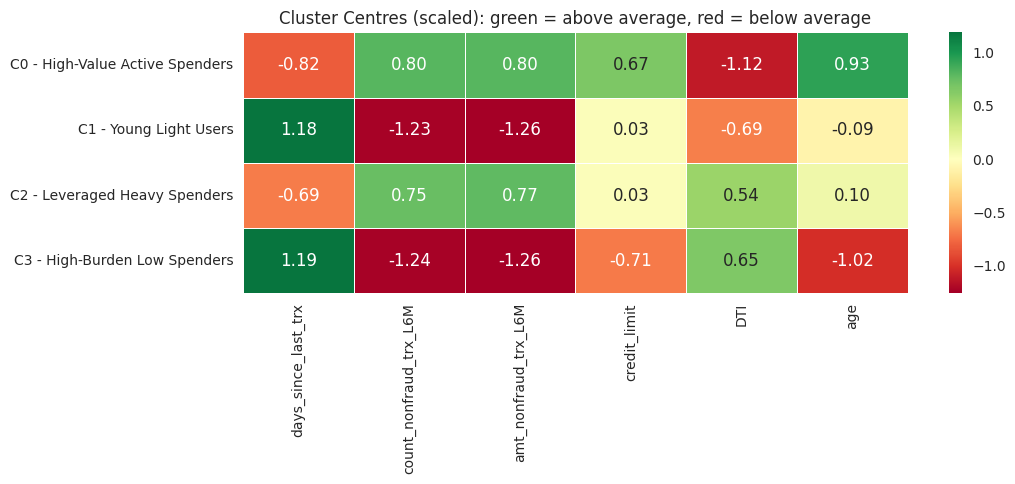

In [32]:
# Heatmap of the cluster centres (still in scaled values)
centres = pd.DataFrame(model.cluster_centers_, columns=feature_cols)

labels = []
for c in centres.index:
    labels.append(f"C{c} - {persona_map[c]}")
centres.index = labels

plt.figure(figsize=(11, 5))
sns.heatmap(centres, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Cluster Centres (scaled): green = above average, red = below average')
plt.tight_layout()
plt.show()

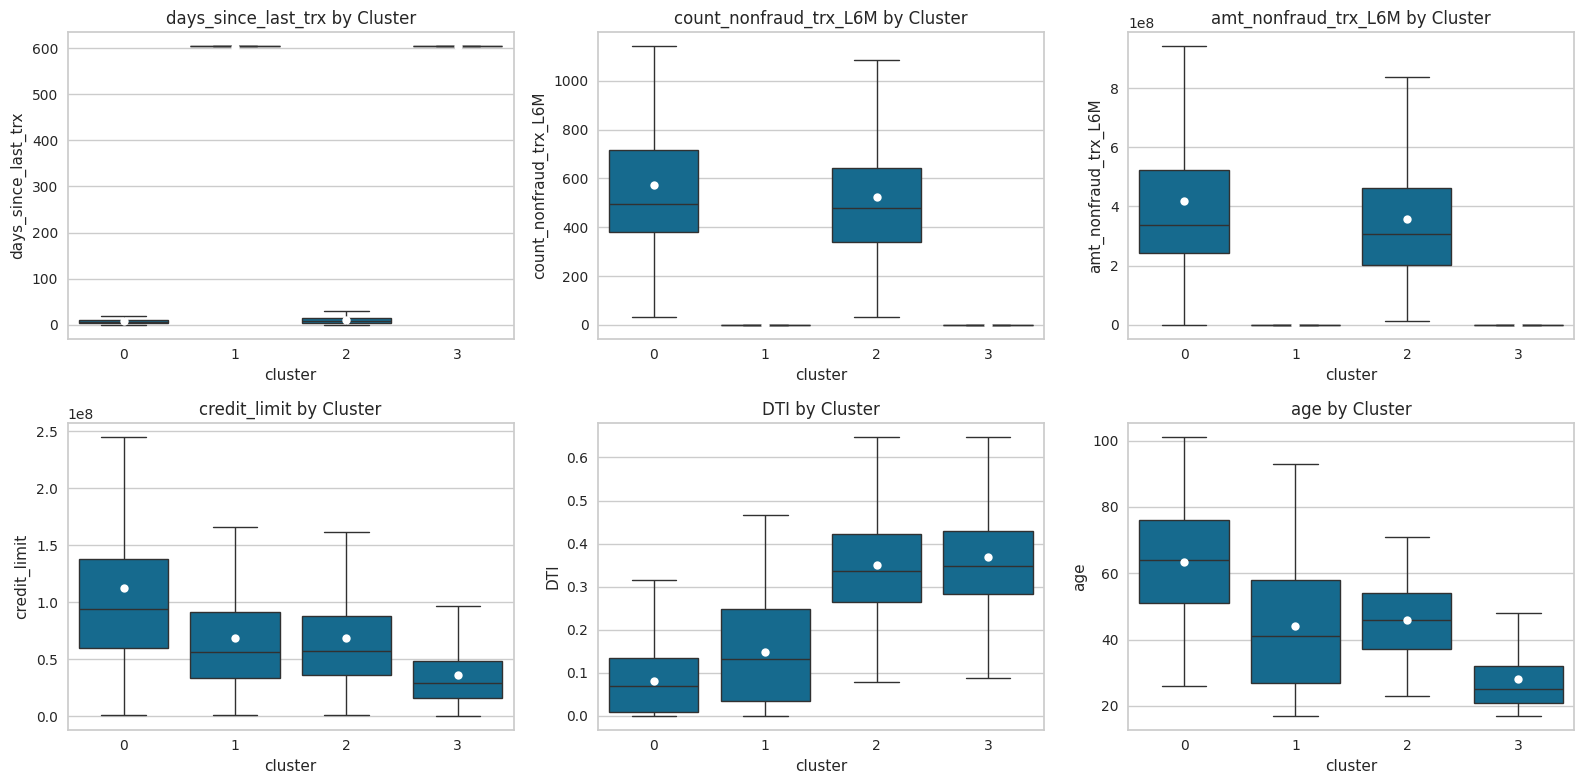

In [33]:
# Boxplot of every feature per cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(
        data=df_result,
        x='cluster',
        y=col,
        ax=axes[i],
        showfliers=False,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}
    )
    axes[i].set_title(f'{col} by Cluster')

plt.tight_layout()
plt.show()

In [34]:
# Print the interpretation so it can be copied straight into the slides
for c in cluster_profile.index:
    p = cluster_profile.loc[c]
    l = levels.loc[c]

    print(f"\nCluster {c} - {l['persona']} ({p['customers']:.0f} customers, {p['share']:.1%})")
    print(f"  [ Recency: {l['Recency']} | Frequency: {l['Frequency']} | Monetary: {l['Monetary']} | "
          f"Limit: {l['CreditLimit']} | DTI: {l['DTI']} | Age: {l['Age']} ]")
    print(f"  Last transacted {p['days_since_last_trx']:.0f} days ago, "
          f"{p['count_nonfraud_trx_L6M']:.0f} transactions in 6 months, "
          f"average spend Rp {p['amt_nonfraud_trx_L6M']:,.0f}")
    print(f"  Average credit limit Rp {p['credit_limit']:,.0f}, "
          f"median DTI {p['DTI']:.2f}, median age {p['age']:.0f}")


Cluster 0 - High-Value Active Spenders (479 customers, 24.7%)
  [ Recency: High | Frequency: High | Monetary: High | Limit: High | DTI: Low | Age: High ]
  Last transacted 6 days ago, 494 transactions in 6 months, average spend Rp 419,526,599
  Average credit limit Rp 112,548,948, median DTI 0.07, median age 64

Cluster 1 - Young Light Users (253 customers, 13.1%)
  [ Recency: Low | Frequency: Low | Monetary: Med | Limit: Low | DTI: Low | Age: Low ]
  Last transacted 604 days ago, 0 transactions in 6 months, average spend Rp 6,626
  Average credit limit Rp 68,755,051, median DTI 0.13, median age 41

Cluster 2 - Leveraged Heavy Spenders (715 customers, 36.9%)
  [ Recency: High | Frequency: High | Monetary: High | Limit: High | DTI: High | Age: High ]
  Last transacted 9 days ago, 477 transactions in 6 months, average spend Rp 356,515,481
  Average credit limit Rp 68,882,540, median DTI 0.34, median age 46

Cluster 3 - High-Burden Low Spenders (491 customers, 25.3%)
  [ Recency: Low | F

---
## E. Business Opportunities & Recommendations

### 12. Segment Value & Prioritisation

Each segment is measured on MDR revenue, revenue **per customer**, and **spend-to-limit ratio** (6-month legitimate spending ÷ approved limit).

Spend-to-limit is the key growth signal: a low ratio means approved capacity is going unused, so extra spending earns MDR income **without** granting new credit. That upside is only safe if DTI is not already stretched, hence the growth score weights capacity 60% and low debt burden 40%.

In [35]:
# Value of each segment
value = df_cluster_full.groupby('cluster').agg({
    'id': 'size',
    'amt_nonfraud_trx_L6M': 'sum',
    'credit_limit': 'sum',
    'DTI': 'median'
})
value.columns = ['customers', 'total_amount', 'total_limit', 'med_DTI']

value['persona'] = value.index.map(persona_map)
value['mdr_revenue'] = MDR_RATE * value['total_amount']
value['share_of_revenue'] = value['mdr_revenue'] / value['mdr_revenue'].sum()
value['rev_per_customer'] = value['mdr_revenue'] / value['customers']

# low ratio = the approved limit is not being used yet
value['spend_to_limit'] = value['total_amount'] / value['total_limit']

print(value[['persona', 'customers', 'mdr_revenue', 'share_of_revenue',
             'rev_per_customer', 'spend_to_limit', 'med_DTI']].round(3))

                            persona  customers   mdr_revenue  \
cluster                                                        
0        High-Value Active Spenders        479  3.014299e+09   
1                 Young Light Users        253  2.514600e+04   
2          Leveraged Heavy Spenders        715  3.823629e+09   
3          High-Burden Low Spenders        491  0.000000e+00   

         share_of_revenue  rev_per_customer  spend_to_limit  med_DTI  
cluster                                                               
0                   0.441       6292898.987           3.728    0.069  
1                   0.000            99.391           0.000    0.132  
2                   0.559       5347732.221           5.176    0.336  
3                   0.000             0.000           0.000    0.349  


In [36]:
# Growth score: 60% untapped capacity, 40% low debt burden
ratio = value['spend_to_limit']
dti = value['med_DTI']

headroom_score = (ratio.max() - ratio) / (ratio.max() - ratio.min())   # 1 = uses its limit the least
risk_score = (dti - dti.min()) / (dti.max() - dti.min())               # 1 = most indebted

value['growth_score'] = (0.6 * headroom_score + 0.4 * (1 - risk_score)).round(2)

ranking = value[['persona', 'spend_to_limit', 'med_DTI', 'growth_score']]
ranking = ranking.sort_values('growth_score', ascending=False)
print(ranking.round(2))

# Pick the segments to act on
top_revenue = value['share_of_revenue'].idxmax()
target_1 = ranking.index[0]
target_2 = ranking.index[1]

print("\n--- Insight ---")
print(f"Largest revenue contributor: Cluster {top_revenue} ({persona_map[top_revenue]}), "
      f"{value.loc[top_revenue, 'share_of_revenue']:.1%} of MDR revenue -> protect, do not push.")
print(f"Primary growth target: Cluster {target_1} ({persona_map[target_1]})")
print(f"Secondary growth target: Cluster {target_2} ({persona_map[target_2]})")
print(f"Portfolio median DTI is {df_cluster_full['DTI'].median():.2f}, "
      f"segments above it should not be pushed to spend more.")

                            persona  spend_to_limit  med_DTI  growth_score
cluster                                                                   
1                 Young Light Users            0.00     0.13          0.91
3          High-Burden Low Spenders            0.00     0.35          0.60
0        High-Value Active Spenders            3.73     0.07          0.57
2          Leveraged Heavy Spenders            5.18     0.34          0.02

--- Insight ---
Largest revenue contributor: Cluster 2 (Leveraged Heavy Spenders), 55.9% of MDR revenue -> protect, do not push.
Primary growth target: Cluster 1 (Young Light Users)
Secondary growth target: Cluster 3 (High-Burden Low Spenders)
Portfolio median DTI is 0.27, segments above it should not be pushed to spend more.


### 13. Business Opportunities per Persona

Keep the entries matching the personas the model actually produced.

**High-Value Active Spenders** — already the biggest MDR contributor, so the risk is churn, not inactivity. Retain with a premium tier, cashback on categories they already use, priority servicing, and limit reviews so a ceiling never blocks a transaction.

**Underused Capacity (Sleeping Potential)** — the clearest growth pocket: capacity is approved and DTI is manageable, so more spending earns MDR without new credit or new default exposure. Use spend-and-get thresholds, merchant partnerships, instalment conversion. Not limit increases.

**Dormant Limit Holders** — consume allocated capital and return nothing. Reactivate with a time-bound win-back offer plus a check on why they stopped (competitor card, expired card, unused PIN). Lower conversion than the sleeping segment, so cap cost per customer.

**Leveraged Heavy Spenders / High-Burden Low Spenders** — a risk segment, not a growth segment. Their DTI is already above the portfolio median, so lifting volume lifts default probability, which erases the 1.5% margin many times over. Tighten limits, monitor closely, offer consolidation or instalment restructuring.

**Young Light Users** — long-term value, not short-term revenue. Cheap digital acquisition, small starter limits with step-ups tied to repayment, lifestyle merchant tie-ins. Keep the budget small.

### 14. Recommendations for the Performance Management Lead

Tied to RevoBank's goal of growing income from product usage: MDR is 1.5% of legitimate transaction value, so income rises with volume and falls with fraud and defaults.

**1. Put the promo budget on the primary growth target from section 12.** It has the most untapped capacity with a below-median DTI, so the extra spending is already covered by approved limits. Run spend-and-get thresholds just above its median transaction amount, category cashback, and 0% instalment on larger baskets. *Metric:* spend-to-limit ratio rising against the section 12 baseline.

**2. Protect, do not push, the largest revenue contributor.** Churn here does the most damage. Proactive limit reviews so transactions are never declined for headroom, a premium service tier, and an alert when a customer's recency drifts past the segment median. *Metric:* retention and revenue per customer holding or rising.

**3. Run a bounded reactivation campaign on the dormant segment.** Time-limited win-back offer, plus a card-expiry and PIN-status check (M1 showed expired cards are a real issue here). Cap cost per reactivated customer and stop if conversion stays below threshold. *Metric:* reactivation rate against that cap.

**4. Exclude the high-DTI segment from all spend-stimulation campaigns.** On a 1.5% margin one default erases the revenue from a very large number of transactions, so growing volume there destroys value even while revenue looks good. Remove from targeting lists, tighten limit increases, offer restructuring instead. *Metric:* median DTI falling, not volume rising.

**5. Attach fraud monitoring to every growth campaign.** M2 showed fraud losses are subtracted straight from MDR profit, and more volume means more absolute exposure. Track the per-cluster fraud rate from section 10 alongside the revenue target, with a rollback trigger if it deteriorates.

**Summary:** grow the segment with capacity and low risk, retain the one that already pays, reactivate the dormant one cheaply, hold back the leveraged one.